In [1]:
data <- read.csv("sdg7_renewable_energy_percent.csv")
head(data)
summary(data)

,Year,Renewable_Energy_Percent
,<int>,<dbl>
1,1990,12.75
2,1991,12.26
3,1992,13.91
4,1993,15.69
5,1994,13.52
6,1995,13.99


      Year      Renewable_Energy_Percent
 Min.   :1990   Min.   :12.26           
 1st Qu.:1998   1st Qu.:15.98           
 Median :2006   Median :18.19           
 Mean   :2006   Mean   :19.30           
 3rd Qu.:2014   3rd Qu.:22.46           
 Max.   :2022   Max.   :29.31           

In [3]:
alpha_prior <- 5
beta_prior <- 5

In [8]:
data$p <- data$Renewable_Energy_Percent / 100
n <- 100  # notional sample size per year
data$Post_Alpha <- alpha_prior + data$p * n
data$Post_Beta  <- beta_prior + (n - data$p * n)

In [9]:
set.seed(42)
data$Prob_Above_70 <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha[i], data$Post_Beta[i])
  mean(samples > 0.7)
})

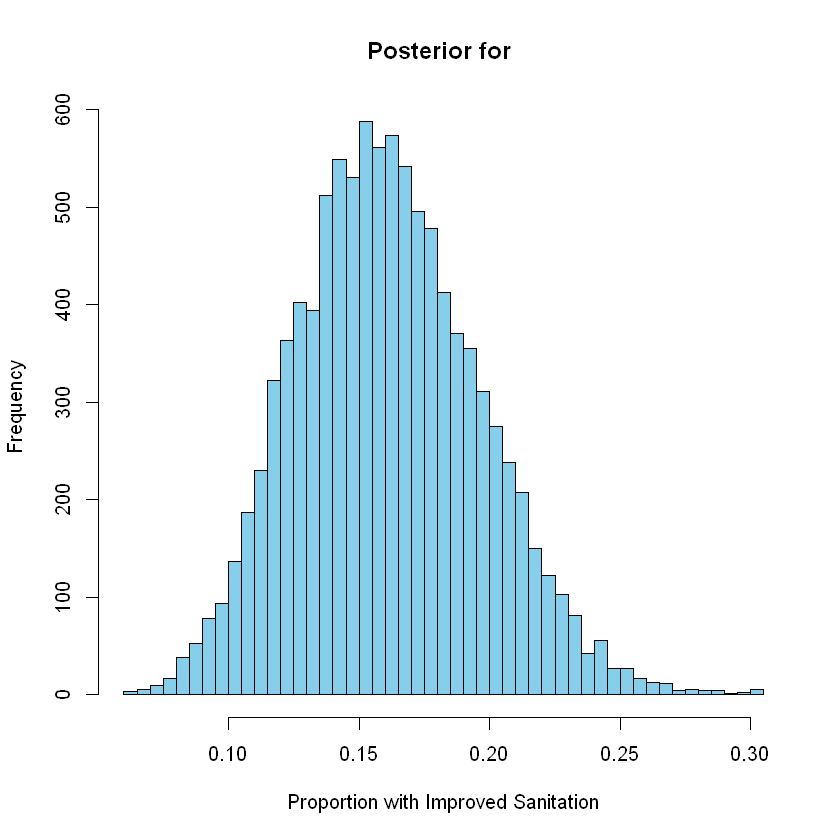

In [10]:
samples <- rbeta(10000, data$Post_Alpha[1], data$Post_Beta[1])
hist(samples, breaks = 50, col = "skyblue",
     main = paste("Posterior for", data$Country[1]),
     xlab = "Proportion with Improved Sanitation")
abline(v = 0.7, col = "red", lwd = 2)

In [12]:
summary_table <- data[c("Year", "Renewable_Energy_Percent", "Prob_Above_70")]
print(summary_table)

   Year Renewable_Energy_Percent Prob_Above_70
1  1990                    12.75             0
2  1991                    12.26             0
3  1992                    13.91             0
4  1993                    15.69             0
5  1994                    13.52             0
6  1995                    13.99             0
7  1996                    17.18             0
8  1997                    16.43             0
9  1998                    15.05             0
10 1999                    17.03             0
11 2000                    15.99             0
12 2001                    16.46             0
13 2002                    17.99             0
14 2003                    15.22             0
15 2004                    15.98             0
16 2005                    18.19             0
17 2006                    17.98             0
18 2007                    20.44             0
19 2008                    19.08             0
20 2009                    18.79             0
21 2010      